In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns 
from scipy import stats as st 
import math 

In [2]:
df = pd.read_csv(r'6. games.csv')

#### 1. Leemos y observamos la información del dataset 'games'

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Verificamos que las columnas 'Name', 'Year_of_Release', 'Genre', 'Critic_Score', 'User_Score', 'Rating' tienen datos faltantes.

#### 2.1 Reemplazar los nombres de las columnas (poner en minúsculas)

In [4]:
new_col_names = []

for old_name in df.columns:
    name_stripped = old_name.strip()
    name_lowered = name_stripped.lower()
    name_no_space = name_lowered.replace(' ', '_')
    new_col_names.append(name_no_space)

df.columns = new_col_names
df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [5]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


#### 2.2 Relleno de valores ausentes en las columnas

In [6]:
df.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

In [7]:
# Rellenamos 1ro las columnas las cuales necesitan cambiar el tipo de datos
df['year_of_release'] = df['year_of_release'].fillna(0)
df['user_score'] = df['user_score'].fillna(0)

#otros
df['critic_score'] = df['critic_score'].fillna(0)
df['user_score'] = df['user_score'].fillna(0)

#Rellenamos las demás columnas con 'desconocido' 
df['name'] = df['name'].fillna('Desconocido')
df['genre'] = df['genre'].fillna('Desconocido')
df['rating'] = df['rating'].fillna('Desconocido')

#### 2.3 Conversion de datos en los tipos necesarios

In [8]:
# Cambio de columna 'year_of_release' a 'int' 
df['year_of_release'] = df['year_of_release'].astype('int')

# Cambio de columna 'user_score' a 'float' pero tenemos que cambiar los valores
# no numéricos (NaN) por eso utilizamos este código
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

In [9]:
# Verificación de datos:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  float64
 9   user_score       14291 non-null  float64
 10  rating           16715 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


Datos limpios y completos

#### 2.4 Cálculo de ventas totales (en todas las regiones) para cada juego y colocar estos valores en una columna separada.

In [10]:
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,0.0,0.0,Desconocido,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,0.0,0.0,Desconocido,31.38


#### 3.Analizar los datos

3.1 Cuántos juegos fueron lanzados en diferentes años?. Son significativos los datos de cada perido?

In [11]:
# Damos una revisada a la cantidad de datos de años que tenemos
df['year_of_release'].unique()

array([2006, 1985, 2008, 2009, 1996, 1989, 1984, 2005, 1999, 2007, 2010,
       2013, 2004, 1990, 1988, 2002, 2001, 2011, 1998, 2015, 2012, 2014,
       1992, 1997, 1993, 1994, 1982, 2016, 2003, 1986, 2000,    0, 1995,
       1991, 1981, 1987, 1980, 1983])

In [12]:
# Revisamos cuantos juegos han sido lanzados en cada uno de los años
df['year_of_release'].value_counts().sort_index()

year_of_release
0        269
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: count, dtype: int64

Existe un incremento considerable de 1993 a 1994 (el doble) de ventas.

In [13]:
# Categorización y agrupación de video juegos por año en 4 categorías 

def era_group(year):
    if year < 1980:
        return 'retro'
    if year <= 1990:
        return 'clasic'
    if year <= 2000:
        return 'gen 6-7'
    if year <= 2010:
        return 'millenial'
    if year <= 2020:
        return 'modern'
    else:
        return 'unkown'
    
df['era_group'] = df['year_of_release'].apply(era_group)
df

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,era_group
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,millenial
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,0.0,0.0,Desconocido,40.24,clasic
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,millenial
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,millenial
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,0.0,0.0,Desconocido,31.38,gen 6-7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,0.0,0.0,Desconocido,0.01,modern
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,0.0,0.0,Desconocido,0.01,millenial
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,0.0,0.0,Desconocido,0.01,modern
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,0.0,0.0,Desconocido,0.01,millenial


3.2 Como varían las ventas de una plataforma a otra. Elige las plataformas con las mayores ventas totales y contruye una distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas y las antiguas en desaparecer?

In [14]:
# Agrupamos las ventas totales por plataforma y año
df.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()

,platform,year_of_release,total_sales
0,2600,0,10.50
1,2600,1980,11.38
2,2600,1981,35.68
3,2600,1982,28.88
4,2600,1983,5.84
...,...,...,...
249,XB,2008,0.18
250,XOne,2013,18.96
251,XOne,2014,54.07
252,XOne,2015,60.14


3.2.1 Elige las plataformas con las mayores ventas totales y contruye una distribución basada en los datos de cada año.

In [15]:
# Buscamos las plataformas con mayores ventas totales a través de los años
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
platform_sales.head()

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
Name: total_sales, dtype: float64

In [16]:
top_platforms = platform_sales.head(5).index
top_platforms

Index(['PS2', 'X360', 'PS3', 'Wii', 'DS'], dtype='object', name='platform')

In [17]:
df['year_of_release'].unique()

array([2006, 1985, 2008, 2009, 1996, 1989, 1984, 2005, 1999, 2007, 2010,
       2013, 2004, 1990, 1988, 2002, 2001, 2011, 1998, 2015, 2012, 2014,
       1992, 1997, 1993, 1994, 1982, 2016, 2003, 1986, 2000,    0, 1995,
       1991, 1981, 1987, 1980, 1983])

In [18]:
# Tenemos que eliminar ese valor "0" para no tener problemas con el dashboard de lineas en el eje x
df = df[df['year_of_release'] != 0]
df['year_of_release'].unique()

array([2006, 1985, 2008, 2009, 1996, 1989, 1984, 2005, 1999, 2007, 2010,
       2013, 2004, 1990, 1988, 2002, 2001, 2011, 1998, 2015, 2012, 2014,
       1992, 1997, 1993, 1994, 1982, 2016, 2003, 1986, 2000, 1995, 1991,
       1981, 1987, 1980, 1983])

In [19]:
# Filtramos los datos para las plataformas principales
top_platforms_data = df[df['platform'].isin(top_platforms)]

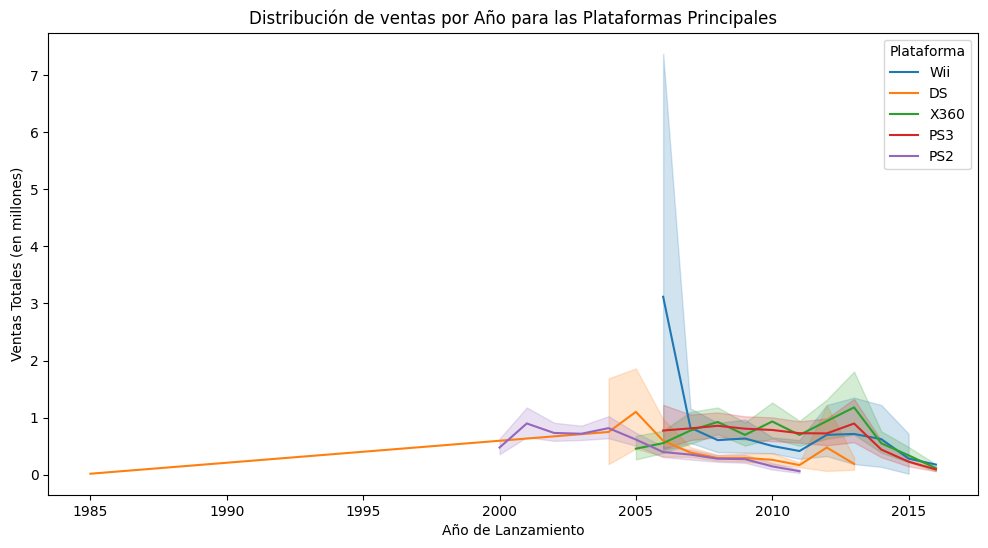

In [20]:
# Creamos la distribución de ventas por año

plt.figure(figsize=(12, 6))
sns.lineplot(data=top_platforms_data, 
             x='year_of_release', 
             y='total_sales', 
             hue='platform')
plt.title('Distribución de ventas por Año para las Plataformas Principales')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Ventas Totales (en millones)')
plt.legend(title='Plataforma')
plt.show()

3.2.2 Análisis de plataformas que solían ser populares y ahora no tienen ventas

In [21]:
# Año más reciente en el dataset
current_year = df['year_of_release'].max()
current_year

np.int64(2016)

In [22]:
# Identificamos las plataformas activas en los últimos 5 años
recent_platforms = df[df['year_of_release'] >= current_year - 5]['platform'].unique()
recent_platforms

array(['PS3', 'X360', 'PS4', '3DS', 'Wii', 'DS', 'XOne', 'WiiU', 'PC',
       'PSV', 'PSP', 'PS2'], dtype=object)

In [23]:
# Ahora filtramos las plataformas que no forman parte de las activas de los últimos 5 años
no_popular_platforms = platform_sales[~platform_sales.index.isin(recent_platforms)]
print("Plataformas populares que ya no tienen ventas:")
no_popular_platforms

Plataformas populares que ya no tienen ventas:


platform
PS      730.86
GBA     317.85
XB      257.74
GB      255.46
NES     251.05
N64     218.68
SNES    200.04
GC      198.93
2600     96.98
SAT      33.59
GEN      30.77
DC       15.95
SCD       1.86
NG        1.44
WS        1.42
TG16      0.16
3DO       0.10
GG        0.04
PCFX      0.03
Name: total_sales, dtype: float64

3.2.3 Análisis de cuanto tardan las plataformas en desaparecer

In [24]:
# Calculamos el rango de años para cada plataforma
platform_years = df.groupby('platform')['year_of_release'].agg(['min', 'max'])
platform_years

,min,max
platform,,
2600,1980,1989
3DO,1994,1995
3DS,2011,2016
DC,1998,2008
DS,1985,2013
GB,1988,2001
GBA,2000,2007
GC,2001,2007
GEN,1990,1994


In [25]:
# Cálculo de la duración de vida de cada plataforma
platform_years['lifespan'] = platform_years['max'] - platform_years['min']
platform_years

,min,max,lifespan
platform,,,
2600,1980,1989,9
3DO,1994,1995,1
3DS,2011,2016,5
DC,1998,2008,10
DS,1985,2013,28
GB,1988,2001,13
GBA,2000,2007,7
GC,2001,2007,6
GEN,1990,1994,4


In [26]:
# Clasificación de plataformas como nuevas o antiguas
threshold_year = current_year -10
platform_years['type'] = platform_years['min'].apply(lambda x: 'new' if x >= threshold_year else 'old')
platform_years

,min,max,lifespan,type
platform,,,,
2600,1980,1989,9,old
3DO,1994,1995,1,old
3DS,2011,2016,5,new
DC,1998,2008,10,old
DS,1985,2013,28,old
GB,1988,2001,13,old
GBA,2000,2007,7,old
GC,2001,2007,6,old
GEN,1990,1994,4,old


** Vamos a crear un gráfico de barras para una mejor visualización **

In [27]:
# Ordenamos las plataformas por tiempo de vida
platform_years_sorted = platform_years.sort_values(by='lifespan', ascending=False)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15668\2295971711.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


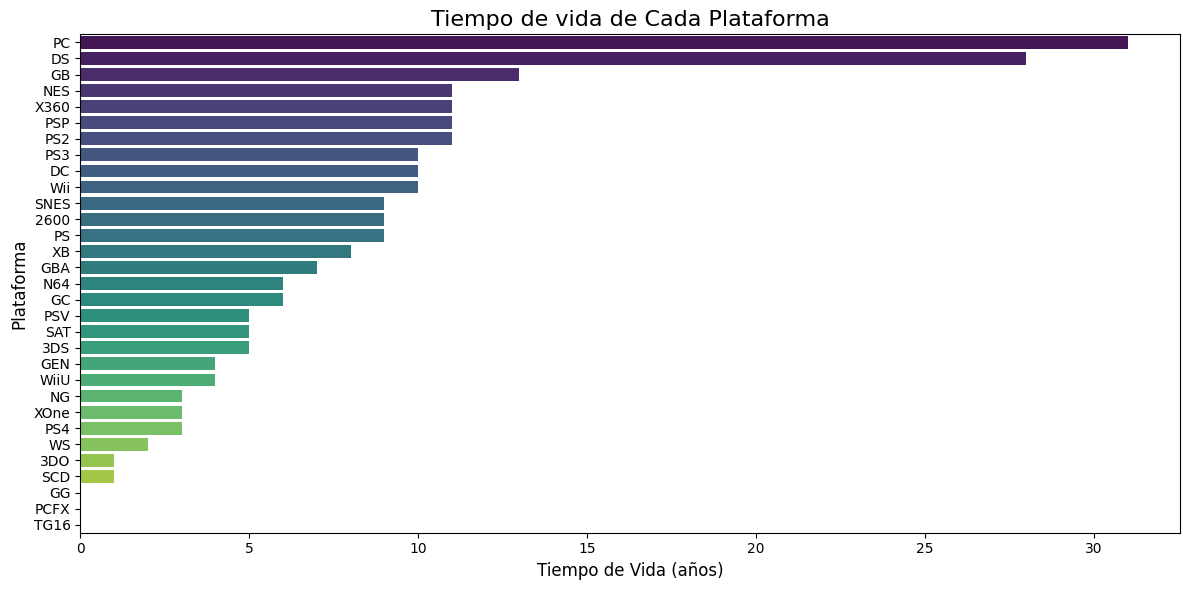

In [28]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=platform_years_sorted.reset_index(),
    x= 'lifespan',
    y='platform',
    palette='viridis'
)
plt.title('Tiempo de vida de Cada Plataforma', fontsize=16)
plt.xlabel('Tiempo de Vida (años)', fontsize=12)
plt.ylabel('Plataforma', fontsize=12)

plt.tight_layout()
plt.show()

In [29]:
# Análisis de duración promedio de vida
avarage_lifespan = platform_years.groupby('type')['lifespan'].mean()
print("Duración promedio de plataformas nuevas y antiguas:")
avarage_lifespan

Duración promedio de plataformas nuevas y antiguas:


type
new    5.714286
old    8.166667
Name: lifespan, dtype: float64

#### 2.5 Construir un modelo para el 2017. Trabajar con datos relevantes e ignorar los datos de años anteriores (periodo de los últimos 5 años). 

2.5.1 Qué plataformas son líderes en ventas globales de todos los juegos desglosados por plataforma?

In [30]:
# Realizamos un filtro tomando en cuenta los últimos 5 años
relevant_years = df[df['year_of_release'] >= 2012]

In [31]:
platform_global_sales  = relevant_years.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("Plataformas líderes en ventas globales (2012-2016):")
platform_global_sales 

Plataformas líderes en ventas globales (2012-2016):


platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
PSP      11.19
Name: total_sales, dtype: float64

2.5.2 Que plataformas crecen y cuales se reducen? Elegir varias plataformas potencialmente rentables

In [32]:
# Cálculo de ventas globales por plataforma y año
platform_trends = df.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()
platform_trends

,platform,year_of_release,total_sales
0,2600,1980,11.38
1,2600,1981,35.68
2,2600,1982,28.88
3,2600,1983,5.84
4,2600,1984,0.27
...,...,...,...
233,XB,2008,0.18
234,XOne,2013,18.96
235,XOne,2014,54.07
236,XOne,2015,60.14


In [33]:
# Gráfico de tendencias de ventas para plataformas principales
top_platforms = platform_global_sales.head(5).index
top_platforms_trends =  platform_trends[platform_trends['platform'].isin(top_platforms)]
top_platforms

Index(['PS4', 'PS3', 'X360', '3DS', 'XOne'], dtype='object', name='platform')

In [34]:
top_platforms_trends.head()

,platform,year_of_release,total_sales
12,3DS,2011,63.20
13,3DS,2012,51.36
14,3DS,2013,56.57
15,3DS,2014,43.76
16,3DS,2015,27.78


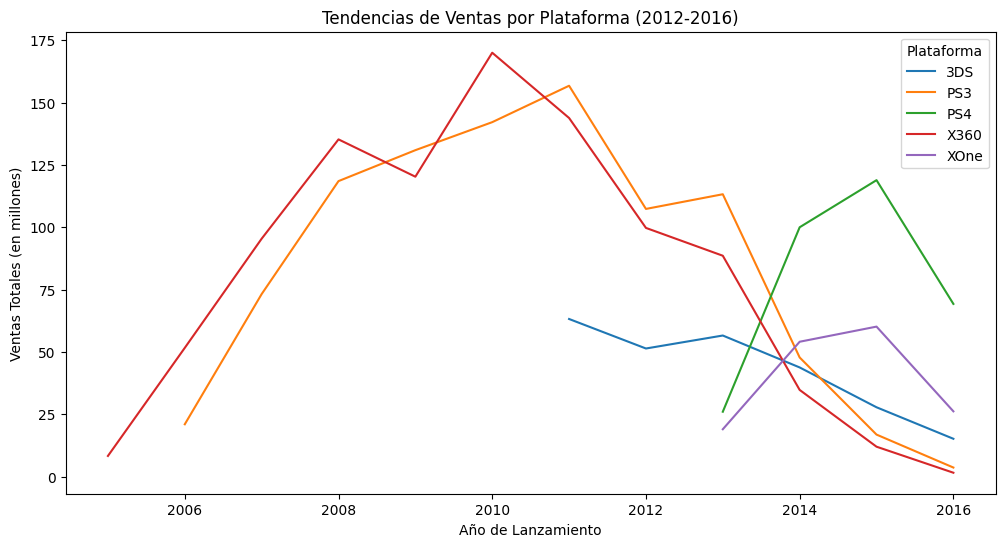

In [35]:
# Gráfico tendencias de ventas para principales plataformas
plt.figure(figsize=(12, 6))
sns.lineplot(data=top_platforms_trends, 
             x = 'year_of_release',
             y = 'total_sales',
             hue = 'platform')
plt.title('Tendencias de Ventas por Plataforma (2012-2016)')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Ventas Totales (en millones)')
plt.legend(title='Plataforma')
plt.show()

#### 3.0 Crear un diagrama de caja para las ventas globales de todos los juegos desglosados por plataforma ¿ Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? Describir hallazgos.

In [36]:
# Filtramos las plataformas con juegos
platform_counts = relevant_years['platform'].value_counts()
platform_counts

platform
PS3     493
PSV     411
3DS     396
PS4     392
X360    292
PC      250
XOne    247
PSP     173
WiiU    147
Wii      54
DS       31
Name: count, dtype: int64

In [37]:
# Filtramos las plataformas que tengan al menos 50 juegos
filtered_platforms = platform_counts[platform_counts > 50].index
filtered_platforms

Index(['PS3', 'PSV', '3DS', 'PS4', 'X360', 'PC', 'XOne', 'PSP', 'WiiU', 'Wii'], dtype='object', name='platform')

In [38]:
filtered_data = relevant_years[relevant_years['platform'].isin(filtered_platforms)]

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15668\1509874588.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


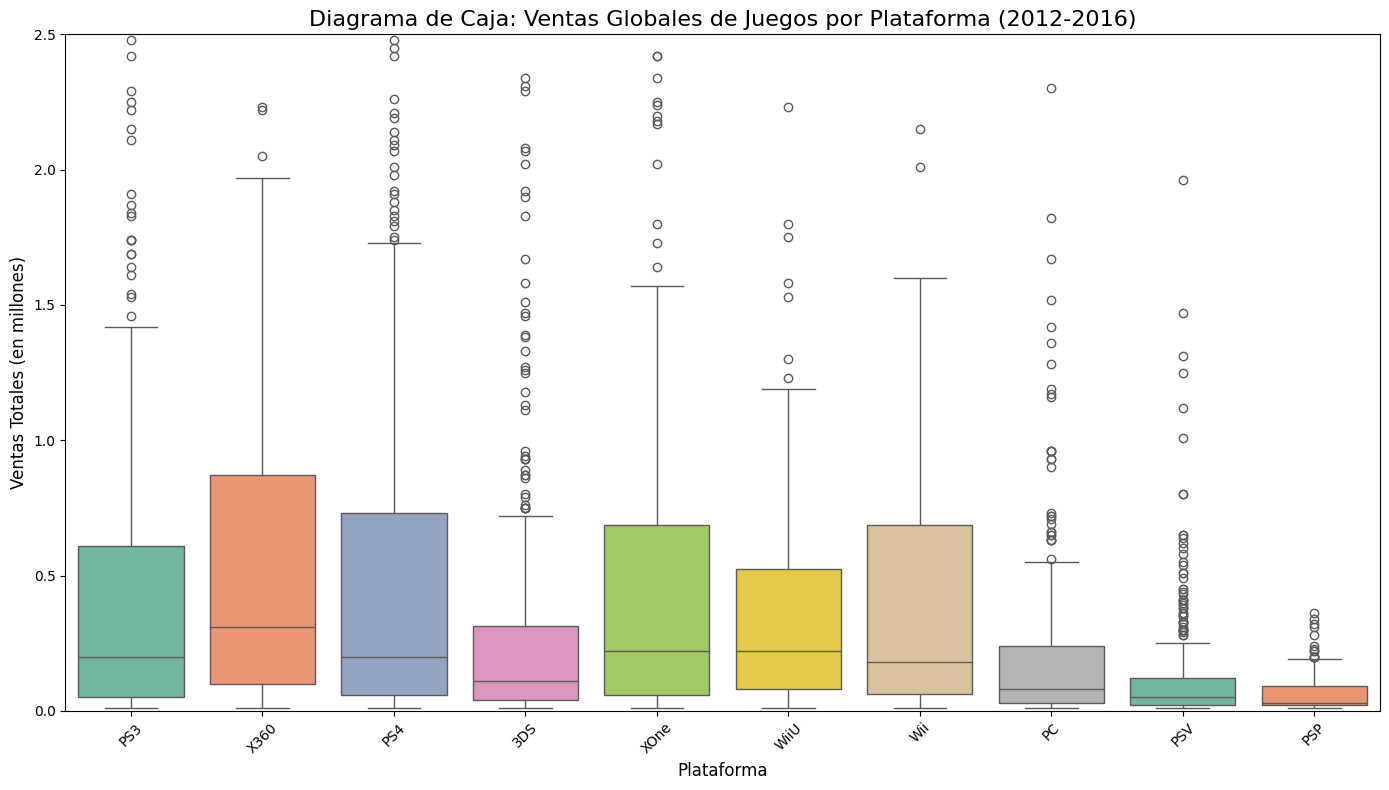

In [39]:
# Creación de diagrama de caja
plt.figure(figsize=(14, 8))
sns.boxplot(
    data= filtered_data,
    x = 'platform',
    y = 'total_sales',
    palette='Set2'
)

plt.title('Diagrama de Caja: Ventas Globales de Juegos por Plataforma (2012-2016)', fontsize=16)
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Ventas Totales (en millones)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 2.5)

plt.tight_layout()
plt.show()

Las ventas por plataforma son significativas. Las ventas promedio en muchas plataformas son casi las mismas a diferencia de sus ventas máximas. 

#### Describe las reseñas de usuarios y profesionales afectan las ventas de una plataforma más popular. Crear un gráfico de dispersión y calcular la correlación entre las  reseñas y las ventas.

In [40]:
platform_global_sales

platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
PSP      11.19
Name: total_sales, dtype: float64

In [41]:
# Plataforma mas popular
most_pop_platform = platform_global_sales.idxmax()
most_pop_platform

'PS4'

In [42]:
# Filtración de datos para esta plataforma
platform_data = relevant_years[relevant_years['platform'] == most_pop_platform]
platform_data

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,era_group
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,0.0,0.0,Desconocido,14.63,modern
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62,modern
77,FIFA 16,PS4,2015,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,8.58,modern
87,Star Wars Battlefront (2015),PS4,2015,Shooter,2.99,3.49,0.22,1.28,0.0,0.0,Desconocido,7.98,modern
92,Call of Duty: Advanced Warfare,PS4,2014,Shooter,2.81,3.48,0.14,1.23,83.0,5.7,M,7.66,modern
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16500,Root Letter,PS4,2016,Adventure,0.00,0.00,0.01,0.00,69.0,7.5,Desconocido,0.01,modern
16503,Shin Hayarigami 2,PS4,2016,Adventure,0.00,0.00,0.01,0.00,0.0,0.0,Desconocido,0.01,modern
16526,Dungeons 2,PS4,2016,Role-Playing,0.01,0.00,0.00,0.00,61.0,7.9,T,0.01,modern
16530,Carmageddon: Max Damage,PS4,2016,Action,0.01,0.00,0.00,0.00,51.0,5.5,M,0.01,modern


Gráfico de dispersión para las reseñas criticos y ventas

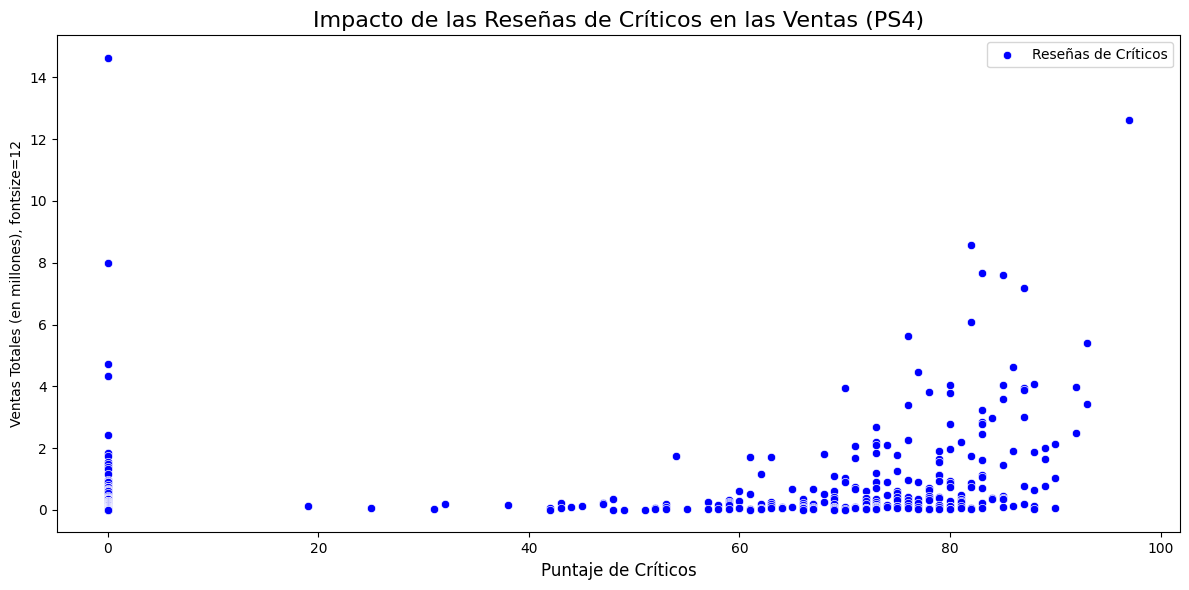

In [43]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data= platform_data,
    x= 'critic_score',
    y= 'total_sales',
    color= 'blue',
    label= 'Reseñas de Críticos'
)

plt.title(f'Impacto de las Reseñas de Críticos en las Ventas ({most_pop_platform})', fontsize=16)
plt.xlabel('Puntaje de Críticos', fontsize=12)
plt.ylabel('Ventas Totales (en millones), fontsize=12')
plt.legend()
plt.tight_layout()
plt.show()

Se puede verificar en el gráfico, que mientras mas altas sean las reseñas, mas ventas se producen en la plataforma PS4.

Cálculo de correlaciones

In [44]:
# Correlación entre reseñas de críticos y ventas
critic_correlation = platform_data[['critic_score', 'total_sales']].corr().iloc[0, 1]
critic_correlation

np.float64(0.22754960627752624)

In [45]:
# Correlación entre usuarios y ventas
user_correlation = platform_data[['user_score', 'total_sales']].corr().iloc[0, 1]
user_correlation

np.float64(0.10493810283090207)

Correlación:

* Valores cercanos a 1 indican una fuerte relación positiva.
* Valores cercanos a -1 indican una fuerte relación negativa.
* Valores cercanos a 0 sugieren poca o ninguna relación.as

#### Describir la distribución general de los juegos por género. ¿Qué se puede decir de los géneros más rentables? ¿Se puede generalizar acerca de los géneros con ventas altas y bajas?

In [46]:
genre_sales = relevant_years.groupby(['platform', 'genre'])['total_sales'].sum().sort_values(ascending=False)
genre_sales

platform  genre       
PS3       Action          115.75
PS4       Action           96.10
          Shooter          88.56
X360      Action           81.60
3DS       Role-Playing     79.30
                           ...  
PSV       Simulation        0.05
PS3       Puzzle            0.04
PC        Puzzle            0.03
PS4       Puzzle            0.02
Wii       Racing            0.01
Name: total_sales, Length: 120, dtype: float64

In [47]:
# Agrupamos por género
genre_data = relevant_years.groupby('genre').agg(
    games_count=('name', 'count'),
    total_sales=('total_sales', 'sum')
).reset_index()

genre_data.sort_values(by='total_sales', ascending=False)

,genre,games_count,total_sales
0,Action,1031,441.12
8,Shooter,235,304.73
7,Role-Playing,370,192.80
10,Sports,268,181.07
3,Misc,192,85.04
4,Platform,85,61.00
6,Racing,115,53.50
2,Fighting,109,44.49
9,Simulation,80,35.12
1,Adventure,302,29.43


In [48]:
# Agregamos una columna de ventas promedio por juego
genre_data['avg_sales_per_game'] = genre_data['total_sales'] / genre_data['games_count']
genre_data.sort_values(by='total_sales', ascending=False)

,genre,games_count,total_sales,avg_sales_per_game
0,Action,1031,441.12,0.427856
8,Shooter,235,304.73,1.296723
7,Role-Playing,370,192.80,0.521081
10,Sports,268,181.07,0.675634
3,Misc,192,85.04,0.442917
4,Platform,85,61.00,0.717647
6,Racing,115,53.50,0.465217
2,Fighting,109,44.49,0.408165
9,Simulation,80,35.12,0.439000
1,Adventure,302,29.43,0.097450


* Los generos más rentables son Action, Shooter, Role-Playing, Sports, Misc y Platform.
* Los generos menos rentables son Puzzle, Strategy, Adventure y Simulation.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15668\2273037703.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_data,


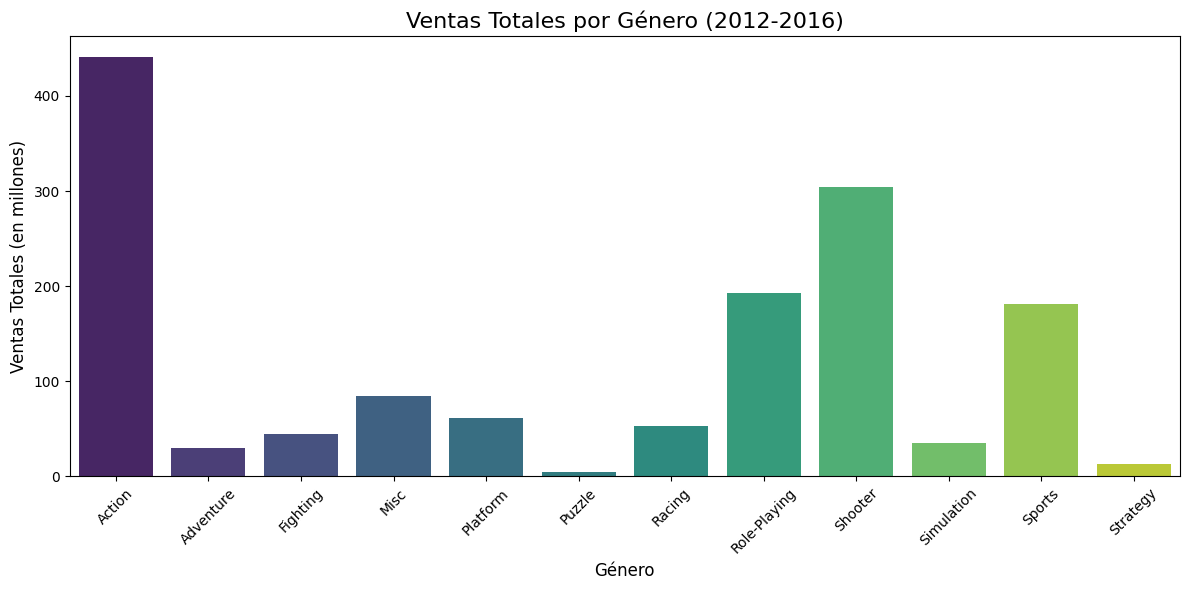

In [49]:
# Gráfico de barras para vizualizar mejor 
plt.figure(figsize=(12, 6))

sns.barplot(data=genre_data, 
            x='genre', 
            y='total_sales',
            palette='viridis')

plt.title('Ventas Totales por Género (2012-2016)', fontsize=16)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Ventas Totales (en millones)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 4. Crea un perfil de usuario para cada Región (NA, UE, JP) y determinar:
* Las cinco plataformas principales. Describir las variaciones en sus cuotas de mercado de una región a otra.
* Los cinco géneros principales. Explicar la diferencia.
* Si las clasificaciones de ESRB afectan a las ventas en regiones individuales.

In [50]:
# Cálculo de  las cinco plataformas principales por región
region_platforms = relevant_years.melt(
    id_vars=['platform', 'genre', 'rating'],
    value_vars=['na_sales', 'eu_sales', 'jp_sales'],
    var_name='region',
    value_name='sales'
)
region_platforms

,platform,genre,rating,region,sales
0,PS3,Action,M,na_sales,7.02
1,X360,Action,M,na_sales,9.66
2,PS4,Shooter,Desconocido,na_sales,6.03
3,3DS,Role-Playing,Desconocido,na_sales,5.28
4,PS3,Shooter,M,na_sales,4.99
...,...,...,...,...,...
8653,PSV,Adventure,Desconocido,jp_sales,0.01
8654,PSV,Misc,Desconocido,jp_sales,0.01
8655,PS3,Action,Desconocido,jp_sales,0.01
8656,PSV,Adventure,Desconocido,jp_sales,0.01


In [51]:
# Renombramos las regiones para tener más claridad
region_platforms['region'] = region_platforms['region'].map({
    'na_sales': 'North America',
    'eu_sales': 'Europe',
    'jp_sales': 'Japan'
})

region_platforms

,platform,genre,rating,region,sales
0,PS3,Action,M,North America,7.02
1,X360,Action,M,North America,9.66
2,PS4,Shooter,Desconocido,North America,6.03
3,3DS,Role-Playing,Desconocido,North America,5.28
4,PS3,Shooter,M,North America,4.99
...,...,...,...,...,...
8653,PSV,Adventure,Desconocido,Japan,0.01
8654,PSV,Misc,Desconocido,Japan,0.01
8655,PS3,Action,Desconocido,Japan,0.01
8656,PSV,Adventure,Desconocido,Japan,0.01


In [55]:
# Calculamos las cinco plataformas principales por región
top_platforms_by_region = region_platforms.groupby(['region', 'platform'])['sales'].sum().reset_index()
top_platforms_by_region = top_platforms_by_region.sort_values(['region', 'sales'], ascending=[True, False])
top_platforms = top_platforms_by_region.groupby('region').head()
top_platforms

,region,platform,sales
4,Europe,PS4,141.09
3,Europe,PS3,106.86
9,Europe,X360,74.52
10,Europe,XOne,51.59
0,Europe,3DS,42.64
11,Japan,3DS,87.79
14,Japan,PS3,35.29
17,Japan,PSV,21.04
15,Japan,PS4,15.96
19,Japan,WiiU,13.01


4.2 Cálculo de los 5 Géneros Principales por Región

In [63]:
# Cálculo de ventas totales por género y región
top_genres_by_region = region_platforms.groupby(['region', 'genre'])['sales'].sum().reset_index()
top_genres_by_region = top_genres_by_region.sort_values(['region', 'sales'], ascending=[True, False])
top_genres = top_genres_by_region.groupby('region').head()
top_genres

,region,genre,sales
0,Europe,Action,159.34
8,Europe,Shooter,113.47
10,Europe,Sports,69.09
7,Europe,Role-Playing,48.53
6,Europe,Racing,27.29
19,Japan,Role-Playing,65.44
12,Japan,Action,52.80
15,Japan,Misc,12.86
21,Japan,Simulation,10.41
14,Japan,Fighting,9.44


4.3 Analizar la influencia de Clasificaciones ESRB en las ventas

In [60]:
# Agrupamos los datos por región y la clasificación ESRB
rating_sales_by_region = region_platforms.groupby(['region', 'rating'])['sales'].sum().reset_index()
rating_sales_by_region = rating_sales_by_region.sort_values(['region', 'sales'], ascending=[True, False])
rating_sales_by_region

,region,rating,sales
3,Europe,M,193.96
1,Europe,E,113.03
0,Europe,Desconocido,91.50
2,Europe,E10+,55.37
4,Europe,T,52.96
5,Japan,Desconocido,108.84
6,Japan,E,28.33
9,Japan,T,26.02
8,Japan,M,21.20
7,Japan,E10+,8.19


Visualización de las Variaciones entre Regiones
* Gráfico de Barras para las plataformas

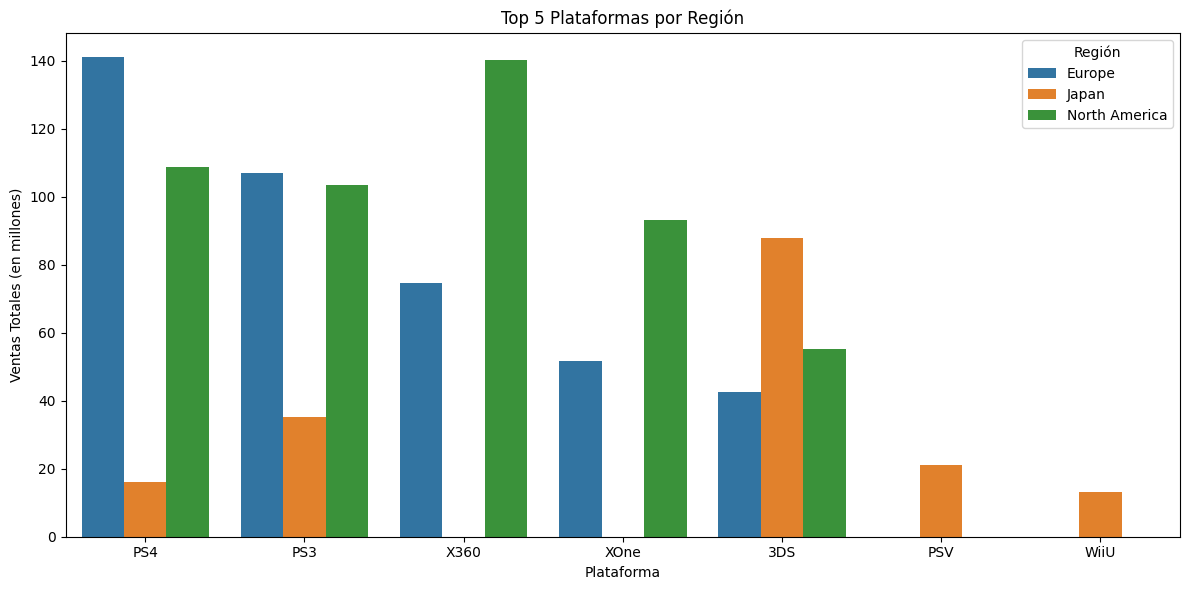

In [61]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_platforms,
            x = 'platform',
            y = 'sales',
            hue = 'region')
plt.title('Top 5 Plataformas por Región')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Totales (en millones)')
plt.legend(title='Región')
plt.tight_layout()
plt.show()

Gráfico de barras para los Géneros

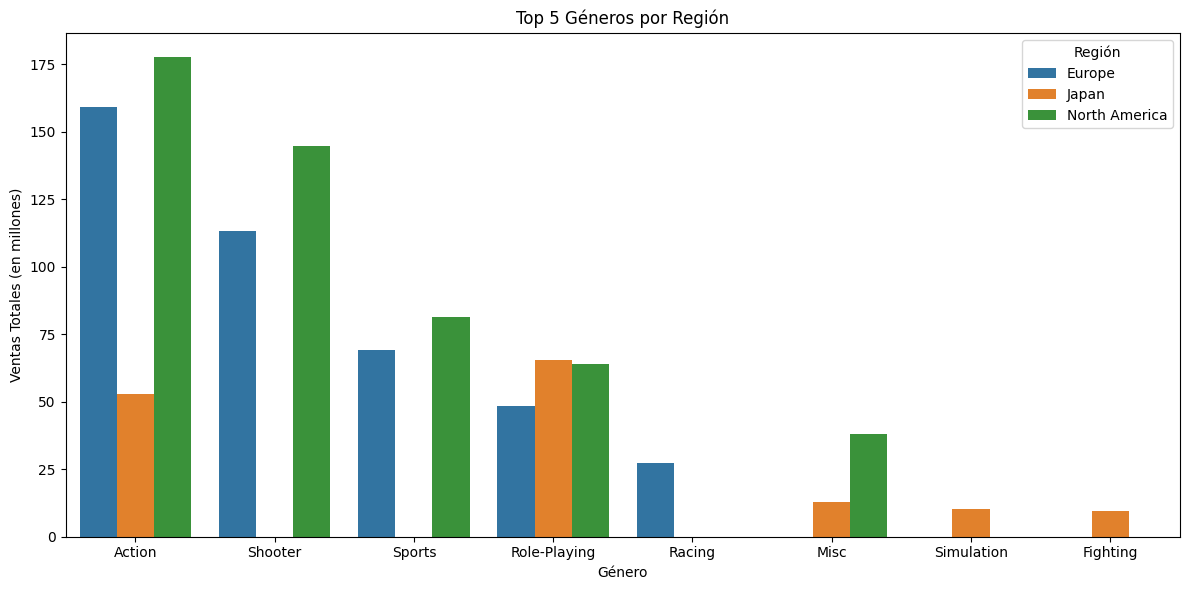

In [64]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_genres, 
            x='genre', 
            y='sales', 
            hue='region')
plt.title('Top 5 Géneros por Región')
plt.xlabel('Género')
plt.ylabel('Ventas Totales (en millones)')
plt.legend(title='Región')
plt.tight_layout()
plt.show()

Gráfico de barras para las Clasificaciones ESRB

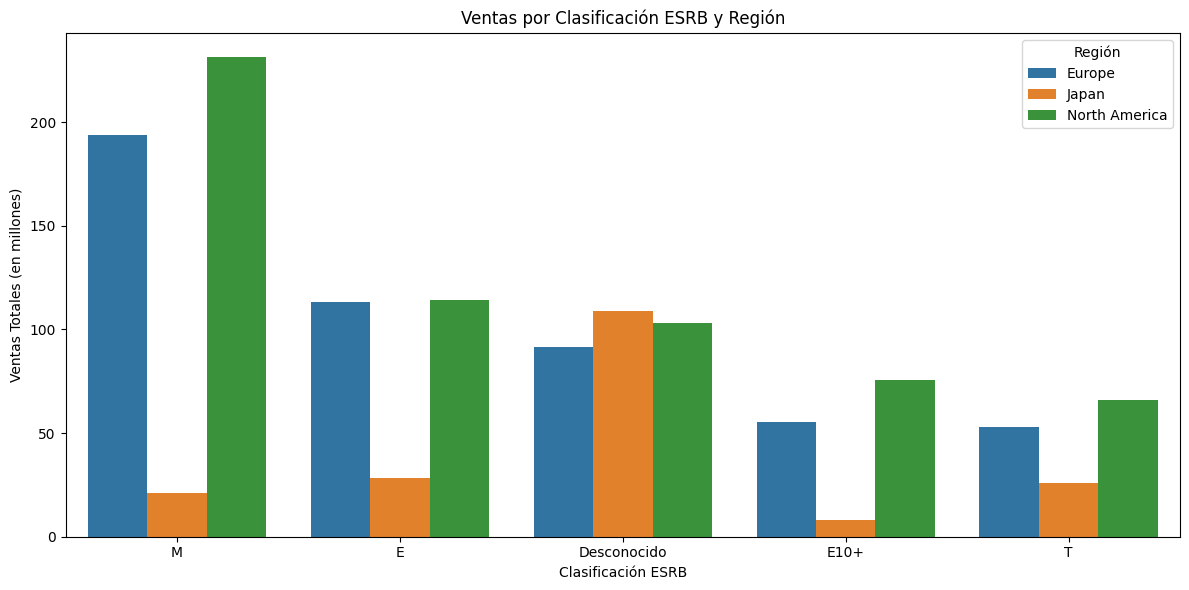

In [65]:
plt.figure(figsize=(12, 6))
sns.barplot(data=rating_sales_by_region, 
            x='rating', 
            y='sales', 
            hue='region')
plt.title('Ventas por Clasificación ESRB y Región')
plt.xlabel('Clasificación ESRB')
plt.ylabel('Ventas Totales (en millones)')
plt.legend(title='Región')
plt.tight_layout()
plt.show()

#### 5. Prueba las siguientes hipótesis:

* Las clasificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
* Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.
* Establece tu mismo el valor de umbral alfa.

5.1 Prueba 1 Xbox & PC

In [66]:
from scipy.stats import ttest_ind, mannwhitneyu

# Configuramos el Umbral Alfa
alpha = 0.05

In [68]:
#Filtramos los datos para Xbox One y PC
xboxone_ratings = relevant_years[(relevant_years['platform'] == 'XOne') & (relevant_years['user_score'].notnull())]['user_score']
pc_ratings = relevant_years[(relevant_years['platform'] == 'PC') & (relevant_years['user_score'].notnull())]['user_score']

In [69]:
# Prueba T de Student
stat, p_value = ttest_ind(xboxone_ratings, pc_ratings, equal_var=False)

if p_value < alpha:
    print(f"Rechazamos H0: Las clasificaciones promedio para Xbox One y PC son diferentes (p = {p_value:.3f}).")
else:
    print(f"No podemos rechazar H0: Las clasificaciones promedio para Xbox One y PC son iguales (p = {p_value:.3f}).")

No podemos rechazar H0: Las clasificaciones promedio para Xbox One y PC son iguales (p = 0.157).


5.2 Prueba 2: Acción y Deportes

In [73]:
action_ratings = relevant_years[(relevant_years['genre'] == 'Action') & (relevant_years['user_score'].notnull())]['user_score']
sports_ratings = relevant_years[(relevant_years['genre'] == 'Sports') & (relevant_years['user_score'].notnull())]['user_score']

In [74]:
# Prueba de Man-Whitney U (en caso de datos no normales)
stat, p_value = mannwhitneyu(action_ratings, sports_ratings, alternative = 'two-sided')

if p_value < alpha:
    print(f"Rechazamos H0: Las clasificaciones promedio para Acción y Deportes son diferentes (p = {p_value:.3f}).")
else:
    print(f"No podemos rechazar H0: Las clasificaciones promedio para Acción y Deportes son iguales (p = {p_value:.3f}).")

No podemos rechazar H0: Las clasificaciones promedio para Acción y Deportes son iguales (p = 0.218).
